In [ ]:
# ==============================================================================
# LECTURE 6: Lennard-Jones Fluid Pair Potential
# Script: LJ
# Author: Edward Maginn, CBE 20260
# Description: 
#   This notebook lets you interactively adjust epsilon and sigma of the LJ
#   potential and see how it changes the shape of the potential.
# ==============================================================================
# On Google Colab, install ipympl and enable interactive widgets
import sys
if "google.colab" in sys.modules:
    %pip install -q ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

Running locally.


In [10]:
def plot_lennard_jones(epsilon_k, sigma):
    """
    Plots the Lennard-Jones potential.
    epsilon_k: Depth of the potential well in Kelvin (epsilon / kB)
    sigma: Distance where potential is zero (nm)
    """
    
    # 1. Define the range of r (distance)
    # We choose a range that covers most small molecules (0.25nm to 1.0nm)
    r = np.linspace(0.24, 1.0, 500)
    
    # 2. Calculate Potential Energy (in Kelvin)
    # V(r) = 4 * epsilon * [ (sigma/r)^12 - (sigma/r)^6 ]
    # We plot V/kB, so we use epsilon_k directly
    V_over_kB = 4 * epsilon_k * ((sigma / r)**12 - (sigma / r)**6)
    
    # 3. Create Plot
    plt.figure(figsize=(8, 6))
    plt.plot(r, V_over_kB, linewidth=3, color='blue', label='LJ Potential')
    
    # 4. Mark the Minimum (Equilibrium separation)
    # The minimum occurs at r = 2^(1/6) * sigma
    r_min = (2**(1/6)) * sigma
    V_min = -epsilon_k
    
    plt.plot(r_min, V_min, 'ro', markersize=10, 
             label=f'Well Depth ($\\epsilon/k_B$) = -{epsilon_k} K')
    
    # 5. Formatting
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.ylim(-400, 200) # Fixed Y-limit to allow visual comparison of well depths
    plt.xlim(0.24, 1.0)
    plt.xlabel('Intermolecular Distance $r$ (nm)', fontsize=12)
    plt.ylabel('Potential Energy / $k_B$ (K)', fontsize=12)
    plt.title(f'Lennard-Jones Potential: $\epsilon/k_B$ = {epsilon_k:.0f} K, $\sigma$ = {sigma:.3f} nm', fontsize=14)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    # N. B. T_boiling is roughly 0.7 * epsilon/kB for noble gases

    plt.show()

# Create the sliders
# Ranges cover Hydrogen (small) to Xenon (large)
interact(plot_lennard_jones, 
         epsilon_k=FloatSlider(value=120, min=30, max=300, step=10, 
                               description='epsilon/kB (K):'),
         sigma=FloatSlider(value=0.34, min=0.25, max=0.45, step=0.01, 
                           description='sigma (nm):'));

interactive(children=(FloatSlider(value=120.0, description='epsilon/kB (K):', max=300.0, min=30.0, step=10.0),…

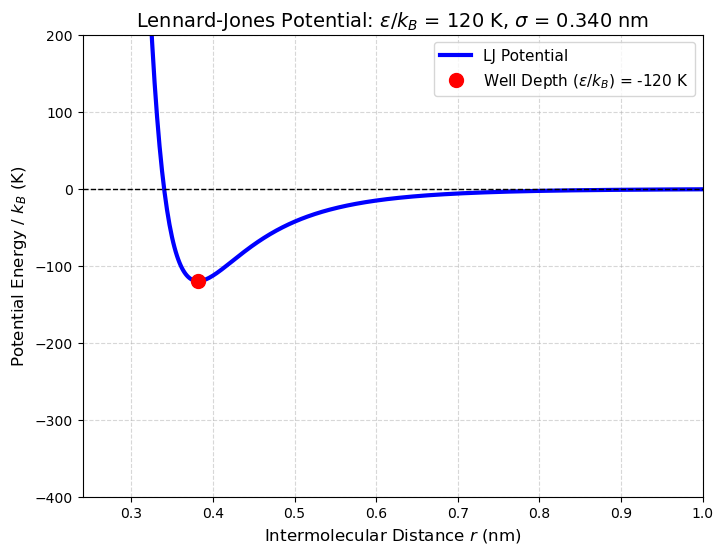

In [ ]:
# Static preview: results for the default inputs above.
# The output is saved so the course website can show it.
# To try other inputs, use the controls above, or open
# this notebook in Colab (badge on the course website).
plot_lennard_jones(epsilon_k=120, sigma=0.34)